In [1]:
import pandas as pd
import numpy as np

# --- Load data ---
df = pd.read_csv("18_nba-clusters.csv")

# --- Select FGA_freq_Spotup_OG and every column to its right ---
start_col = "FGA_freq_Spotup_OG"
X = df.loc[:, start_col:]
feature_names = X.columns.tolist()

# --- Standardize (z-score) each column ---
mu = X.mean(axis=0)
sd = X.std(axis=0, ddof=0)
Z = (X - mu) / sd

# --- Condense into a matrix for PCA ---
Z_matrix = Z.values

# --- PCA via eigendecomposition of the correlation matrix ---
C = np.cov(Z_matrix, rowvar=False, ddof=0)
eigvals, eigvecs = np.linalg.eigh(C)

order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

explained_var_ratio = eigvals / eigvals.sum()

# --- Report first 4 PCs ---
n_components = 4
pc_loadings = pd.DataFrame(
    eigvecs[:, :n_components],
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

print("Loadings (eigenvectors) for first 4 PCs:")
display(pc_loadings)

print("\nProportion of variance explained:")
for i in range(n_components):
    print(f"PC{i+1}: {explained_var_ratio[i]*100:.2f}%")

print(f"\nCumulative variance explained by first 4 PCs: {explained_var_ratio[:n_components].sum()*100:.2f}%")

# --- (Optional) Project data onto the first 4 PCs ---
scores = Z_matrix @ eigvecs[:, :n_components]
scores_df = pd.DataFrame(scores, columns=[f"PC{i+1}" for i in range(n_components)])
scores_df.head()

Loadings (eigenvectors) for first 4 PCs:


,PC1,PC2,PC3,PC4
FGA_freq_Spotup_OG,-0.245825,0.638843,0.355386,-0.187102
FGA_freq_PRRollMan_OG,0.439364,-0.002629,0.042643,0.003258
FGA_freq_Postup_OG,0.297641,-0.275324,0.628073,0.399979
FGA_freq_Cut_OG,0.443637,0.010391,-0.353047,-0.052832
FGA_freq_OffRebound_OG,0.441251,-0.034028,-0.274106,-0.069946
FGA_freq_PRBallHandler_OG,-0.362737,-0.403493,-0.281683,-0.338040
FGA_freq_Isolation_OG,-0.208586,-0.589997,0.255122,-0.067780
FGA_freq_OffScreenOrHandoff_OG,-0.302219,0.062456,-0.364964,0.823681



Proportion of variance explained:
PC1: 43.50%
PC2: 19.33%
PC3: 10.74%
PC4: 10.21%

Cumulative variance explained by first 4 PCs: 83.79%


,PC1,PC2,PC3,PC4
0,-0.553792,0.216176,0.953089,-0.979870
1,-1.411190,1.345613,1.080440,-0.967590
2,2.193765,0.760838,0.210516,-0.472357
3,2.050125,-0.574052,2.204138,1.143160
4,1.813574,0.351281,0.990344,0.438148


In [2]:
# --- Attach player identity to PC scores ---
player_pcs = pd.concat(
    [df[["PLAYER_NAME", "player_szn"]].reset_index(drop=True), scores_df],
    axis=1
)

display(player_pcs)

# Optional: sort by a given PC to see top/bottom players
player_pcs.sort_values("PC1", ascending=False).head(10)

,PLAYER_NAME,player_szn,PC1,PC2,PC3,PC4
0,Grant Hill,Grant Hill 2012,-0.553792,0.216176,0.953089,-0.979870
1,Jason Kidd,Jason Kidd 2012,-1.411190,1.345613,1.080440,-0.967590
2,Kurt Thomas,Kurt Thomas 2012,2.193765,0.760838,0.210516,-0.472357
3,Kevin Garnett,Kevin Garnett 2012,2.050125,-0.574052,2.204138,1.143160
4,Kevin Garnett,Kevin Garnett 2013,1.813574,0.351281,0.990344,0.438148
...,...,...,...,...,...,...
4604,Quenton Jackson,Quenton Jackson 2022,-1.488528,0.596422,0.116390,-1.427708
4605,Jamal Cain,Jamal Cain 2022,1.608812,1.253853,-0.871199,-0.916800
4606,Justin Minaya,Justin Minaya 2022,-1.153558,2.791519,1.467823,-1.031671
4607,Simone Fontecchio,Simone Fontecchio 2022,-1.489209,1.352231,-0.889868,2.027496


,PLAYER_NAME,player_szn,PC1,PC2,PC3,PC4
3253,Alex Stepheson,Alex Stepheson 2015,4.516567,-0.370123,-2.945236,-0.936908
4599,Moussa Diabate,Moussa Diabate 2022,4.516567,-0.370123,-2.945236,-0.936908
2943,Jack Cooley,Jack Cooley 2017,4.516567,-0.370123,-2.945236,-0.936908
2836,Noah Vonleh,Noah Vonleh 2022,4.516567,-0.370123,-2.945236,-0.936908
1515,Ed Davis,Ed Davis 2020,4.258102,-0.222362,-3.006669,-0.845805
443,Andrew Bogut,Andrew Bogut 2018,4.128869,-0.148482,-3.037386,-0.800254
4062,Johnathan Williams,Johnathan Williams 2019,4.099046,-0.131432,-3.044474,-0.789742
712,Lou Amundson,Lou Amundson 2013,4.083512,-0.236941,-1.668623,-0.635485
1502,Cole Aldrich,Cole Aldrich 2012,4.077662,-0.166869,-2.474747,-0.720213
4192,Moses Brown,Moses Brown 2020,4.074952,-0.181208,-2.283788,-0.698593


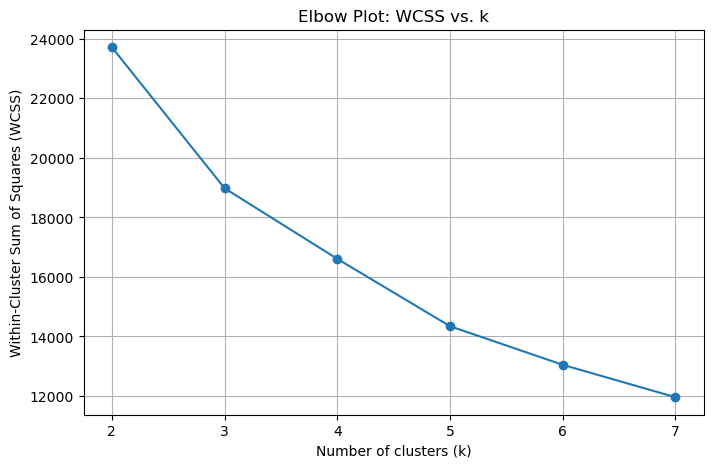

,k,WCSS
0,2,23719.098790
1,3,18980.336258
2,4,16606.583266
3,5,14343.237540
4,6,13045.951875
5,7,11957.012363


In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = range(2, 8)
wcss = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Z_matrix)   # use Z if you're on the sklearn-based version
    wcss.append(km.inertia_)

# --- Plot WCSS vs k ---
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (WCSS)")
plt.title("Elbow Plot: WCSS vs. k")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# --- Optional: table of k vs WCSS ---
wcss_df = pd.DataFrame({"k": list(k_values), "WCSS": wcss})
display(wcss_df)

Cluster sizes:
cluster
0    1354
1     611
2     744
3     825
4    1075
Name: count, dtype: int64

Cluster mean values (standardized features):


,FGA_freq_Spotup_OG,FGA_freq_PRRollMan_OG,FGA_freq_Postup_OG,FGA_freq_Cut_OG,FGA_freq_OffRebound_OG,FGA_freq_PRBallHandler_OG,FGA_freq_Isolation_OG,FGA_freq_OffScreenOrHandoff_OG
cluster,,,,,,,,
0,-0.341908,-0.639339,-0.352236,-0.633496,-0.580963,1.225086,0.953941,0.055290
1,-0.667921,0.866975,1.967869,0.352175,0.459928,-0.789835,0.005069,-0.618175
2,-0.974236,1.455645,0.121703,1.639077,1.564139,-0.855611,-0.688435,-0.828591
3,0.279906,-0.596623,-0.454176,-0.466612,-0.524370,0.001992,-0.256990,1.618148
4,1.269724,-0.237064,-0.410505,-0.178553,-0.209774,-0.503485,-0.530717,-0.386659



Cluster 0 (n=1354) - sample of 50 players:
['LeBron James', 'Tim Frazier', 'Caris LeVert', 'Zavier Simpson', 'Jaylen Brown', 'Anthony Edwards', 'Donovan Mitchell', 'Joe Young', 'Jeff Teague', 'Kyrie Irving', 'Cory Joseph', 'Matthew Dellavedova', 'Jeremy Lin', 'Tobias Harris', 'Michael Carter-Williams', 'Kyrie Irving', 'Kris Dunn', 'Brandon Ingram', 'Pablo Prigioni', 'LeBron James', 'James Bouknight', 'Coby White', 'Alec Burks', 'Danilo Gallinari', 'Fred VanVleet', 'Brandon Knight', 'Tobias Harris', 'Kendall Marshall', 'Steve Blake', 'Shannon Brown', 'Zach LaVine', 'Jalen Williams', 'O.J. Mayo', 'Tyus Jones', 'Josh Christopher', 'T.J. McConnell', 'Dennis Schroder', 'Paolo Banchero', 'Iman Shumpert', 'Chris Paul', 'LeBron James', 'T.J. McConnell', 'Kyrie Irving', 'Blake Wesley', 'Keifer Sykes', 'Jeff Green', 'Tony Parker', 'Kemba Walker', 'Eric Bledsoe', 'Cory Joseph']

Cluster 1 (n=611) - sample of 50 players:
['Dwight Howard', 'Marreese Speights', 'Carmelo Anthony', 'Naz Reid', 'Taj G

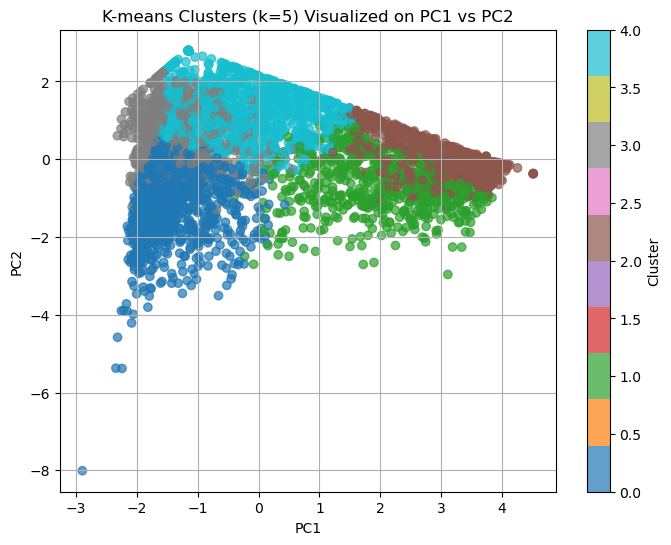

In [15]:
#Choosing k = 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Fit K-means with k=5 ---
k = 5
km5 = KMeans(n_clusters=k, random_state=42, n_init=10)
cluster_labels = km5.fit_predict(Z_matrix)

# --- Attach cluster labels to original data ---
df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

# (1) Cluster mean values (on the standardized features, with cluster sizes)
Z_df = pd.DataFrame(Z_matrix, columns=feature_names)
Z_df["cluster"] = cluster_labels

cluster_means = Z_df.groupby("cluster")[feature_names].mean()
cluster_sizes = Z_df["cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)
print("\nCluster mean values (standardized features):")
display(cluster_means)

# (2) Randomly selected 50 player names from each cluster
np.random.seed(42)
for c in sorted(df_clustered["cluster"].unique()):
    players_in_cluster = df_clustered.loc[df_clustered["cluster"] == c, "PLAYER_NAME"]
    sample_size = min(50, len(players_in_cluster))
    sample = players_in_cluster.sample(n=sample_size, random_state=42).tolist()
    print(f"\nCluster {c} (n={len(players_in_cluster)}) - sample of {sample_size} players:")
    print(sample)

# (3) Visualization along PC1 and PC2, colored by cluster, no player labels
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    scores_df["PC1"], scores_df["PC2"],
    c=cluster_labels, cmap="tab10", alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clusters (k=5) Visualized on PC1 vs PC2")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

In [17]:
import pandas as pd
import numpy as np

players_of_interest = ["Jerami Grant 2022", "Dejounte Murray 2022", "Donovan Mitchell 2022"]

# --- Combine player identity, cluster label, and PC scores into one table ---
combined = pd.concat(
    [df_clustered[["PLAYER_NAME", "player_szn", "cluster"]].reset_index(drop=True),
     scores_df.reset_index(drop=True)],
    axis=1
)

# (A) Cluster assignment for each player-season
subset = combined[combined["player_szn"].isin(players_of_interest)]
print("(A) Cluster assignments:")
display(subset[["player_szn", "cluster"]])

# (B) PC scores for each player-season
print("\n(B) PC scores for selected players:")
display(subset[["player_szn", "PC1", "PC2", "PC3", "PC4"]])

# Mean and variance of each PC across all players
pc_cols = ["PC1", "PC2", "PC3", "PC4"]
pc_means = scores_df[pc_cols].mean()
pc_vars = scores_df[pc_cols].var(ddof=0)

print("\nMean of each PC (across all players):")
print(pc_means)

print("\nVariance of each PC (across all players):")
print(pc_vars)

(A) Cluster assignments:


,player_szn,cluster
2765,Jerami Grant 2022,0
3326,Dejounte Murray 2022,0
3590,Donovan Mitchell 2022,0



(B) PC scores for selected players:


,player_szn,PC1,PC2,PC3,PC4
2765,Jerami Grant 2022,-0.563110,-0.234729,0.869042,0.490936
3326,Dejounte Murray 2022,-1.750626,-1.863290,-0.102629,-0.835007
3590,Donovan Mitchell 2022,-1.769560,-1.317853,-0.725558,0.136105



Mean of each PC (across all players):
PC1   -2.140473e-16
PC2   -2.241162e-16
PC3   -1.127326e-17
PC4   -2.537928e-16
dtype: float64

Variance of each PC (across all players):
PC1    3.480300
PC2    1.546516
PC3    0.859574
PC4    0.816456
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

players_of_interest = ["Jerami Grant 2022", "Dejounte Murray 2022", "Donovan Mitchell 2022"]

pc_cols = ["PC1", "PC2", "PC3", "PC4"]

# Case-insensitive lookup of target rows
mask = combined["player_szn"].str.lower().isin([p.lower() for p in players_of_interest])
targets = combined[mask]

all_pc_values = combined[pc_cols].values

for _, target_row in targets.iterrows():
    target_name = target_row["player_szn"]
    target_cluster = target_row["cluster"]
    target_vec = target_row[pc_cols].values.astype(float).reshape(1, -1)

    # --- (1) Smallest Euclidean distance across ALL players (full PC space) ---
    dists_all = cdist(target_vec, all_pc_values, metric="euclidean").flatten()
    combined_temp = combined.copy()
    combined_temp["dist"] = dists_all
    nearest_all = (
        combined_temp[combined_temp["player_szn"].str.lower() != target_name.lower()]
        .sort_values("dist")
        .head(5)
    )
    print(f"\n=== {target_name} ===")
    print("Top 5 nearest players (all players, full PC space):")
    display(nearest_all[["player_szn", "cluster", "dist"]])

    # --- (2) Smallest Euclidean distance WITHIN the same cluster ---
    same_cluster = combined_temp[combined_temp["cluster"] == target_cluster]
    nearest_in_cluster = (
        same_cluster[same_cluster["player_szn"].str.lower() != target_name.lower()]
        .sort_values("dist")
        .head(5)
    )
    print(f"Top 5 nearest players (within cluster {target_cluster} only):")
    display(nearest_in_cluster[["player_szn", "cluster", "dist"]])

    # --- (3) Smallest Euclidean distance by PC1 only ---
    target_pc1 = target_row["PC1"]
    combined_temp["pc1_dist"] = (combined_temp["PC1"] - target_pc1).abs()
    nearest_pc1 = (
        combined_temp[combined_temp["player_szn"].str.lower() != target_name.lower()]
        .sort_values("pc1_dist")
        .head(5)
    )
    print("Top 5 nearest players (by PC1 only):")
    display(nearest_pc1[["player_szn", "cluster", "PC1", "pc1_dist"]])